# Forecasting toy: the 2026-warmest-year equation model

Same shape as `toy_linear_flow`, but the real prediction constraints: five leaves
(`trend`, `enso`, `volcanic`, plus derived `anomaly`, `record`) pinned by elicited
means/tail bounds, tied together by the structural equation
`anomaly = trend + 0.075*enso - volcanic ~ N(0, 0.035)` and the threshold
`record = ind(anomaly > 1.60)`.

The question this toy makes visible: the flow satisfies the residual's first two
moments, but does it keep the residual **independent** of the right-hand side, or
does it anti-correlate in the tail and clip `P(anomaly > 1.60)` below the
independent max-entropy target?

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
import matplotlib.pyplot as plt
from calibrated_response.models.variable import BinaryVariable, ContinuousVariable
from calibrated_response.models.natural_response import parse_natural_syntax as P
from calibrated_response.maxent_sampler.distribution_builder import DistributionBuilder

RECORD, NOISE, HAND_MC = 1.60, 0.035, 0.067   # threshold, eqn noise sd, hand Monte-Carlo ref

In [15]:
variables = [
    # BinaryVariable(name="record_2026", description="2026 warmest year on record"),
    ContinuousVariable(name="anomaly_2026", description="2026 global anomaly",
                       lower_bound=1.25, upper_bound=1.85, unit="C"),
    ContinuousVariable(name="trend_2026", description="ENSO/volcano-free baseline",
                       lower_bound=1.40, upper_bound=1.66, unit="C"),
    ContinuousVariable(name="enso_oni_2026", description="2026 annual-mean ONI",
                       lower_bound=-2.0, upper_bound=2.0, unit="index"),
    ContinuousVariable(name="volcanic_2026", description="volcanic cooling in 2026",
                       lower_bound=0.0, upper_bound=0.35, unit="C"),
]
estimates = [P(e) for e in [
    "E[trend_2026] = 1.53", "P(trend_2026 > 1.60) < 0.05", "P(trend_2026 < 1.46) < 0.05",
    "E[enso_oni_2026] = -0.2", "P(enso_oni_2026 > 0.5) < 0.18", "P(enso_oni_2026 < -1.1) < 0.10",
    "E[volcanic_2026] = 0.015", "P(volcanic_2026 > 0.10) < 0.06",
    "anomaly_2026 = trend_2026 + 0.075*enso_oni_2026 - volcanic_2026 ~ N(0, 0.035)",
    # "P(record_2026 > 0.5 | anomaly_2026 > 1.60) = 0.98",
    # "P(record_2026 > 0.5 | anomaly_2026 < 1.60) = 0.02"
]]

b = DistributionBuilder(variables, estimates, n_layers=8, hidden=64)
b.build(target_variable="anomaly_2026", steps=2000, lr=2e-3, n_samples=2000, seed=0)
print("done — joint entropy (nats):", round(b.entropy(), 3))

done — joint entropy (nats): -5.261


In [16]:
d = b.sample_dict(200000, seed=1)
tr, on, vo, an = d["trend_2026"], d["enso_oni_2026"], d["volcanic_2026"], d["anomaly_2026"]
rhs = tr + 0.075 * on - vo
r = an - rhs

# max-entropy target: same leaf marginals, reconvolved *independently*
rng = np.random.default_rng(0)
recon = rng.permutation(tr) + 0.075 * rng.permutation(on) - rng.permutation(vo) + rng.normal(0, NOISE, len(tr))

print(f"residual mean/std : {r.mean():+.4f} / {r.std():.4f}   (true 0 / {NOISE})")
print(f"corr(rhs, residual): {np.corrcoef(rhs, r)[0,1]:+.3f}   (want ~0; negative = tail-clipping)")
print(f"P_flow  (derived)  : {np.mean(an > RECORD):.4f}")
print(f"P_maxent (indep)   : {np.mean(recon > RECORD):.4f}")
print(f"hand MC reference  : {HAND_MC}")
for row in b.constraint_report():
    print(f"  {row['estimate']:<40} target={row['target']} fitted={row['fitted']:.3f}")

residual mean/std : -0.0030 / 0.0374   (true 0 / 0.035)
corr(rhs, residual): +0.023   (want ~0; negative = tail-clipping)
P_flow  (derived)  : 0.0846
P_maxent (indep)   : 0.0881
hand MC reference  : 0.067
  E[trend_2026] = 1.53                     target=1.53 fitted=1.528
  P(trend_2026 > 1.6) < 0.05               target=0.05 fitted=0.042
  P(trend_2026 < 1.46) < 0.05              target=0.05 fitted=0.049
  E[enso_oni_2026] = -0.2                  target=-0.2 fitted=-0.184
  P(enso_oni_2026 > 0.5) < 0.18            target=0.18 fitted=0.163
  P(enso_oni_2026 < -1.1) < 0.1            target=0.1 fitted=0.077
  E[volcanic_2026] = 0.015                 target=0.015 fitted=0.027
  P(volcanic_2026 > 0.1) < 0.06            target=0.06 fitted=0.024
  anomaly_2026 = trend_2026 + 0.075*enso_oni_2026 - volcanic_2026 ~ N(0, 0.035) target=0.035 fitted=0.037


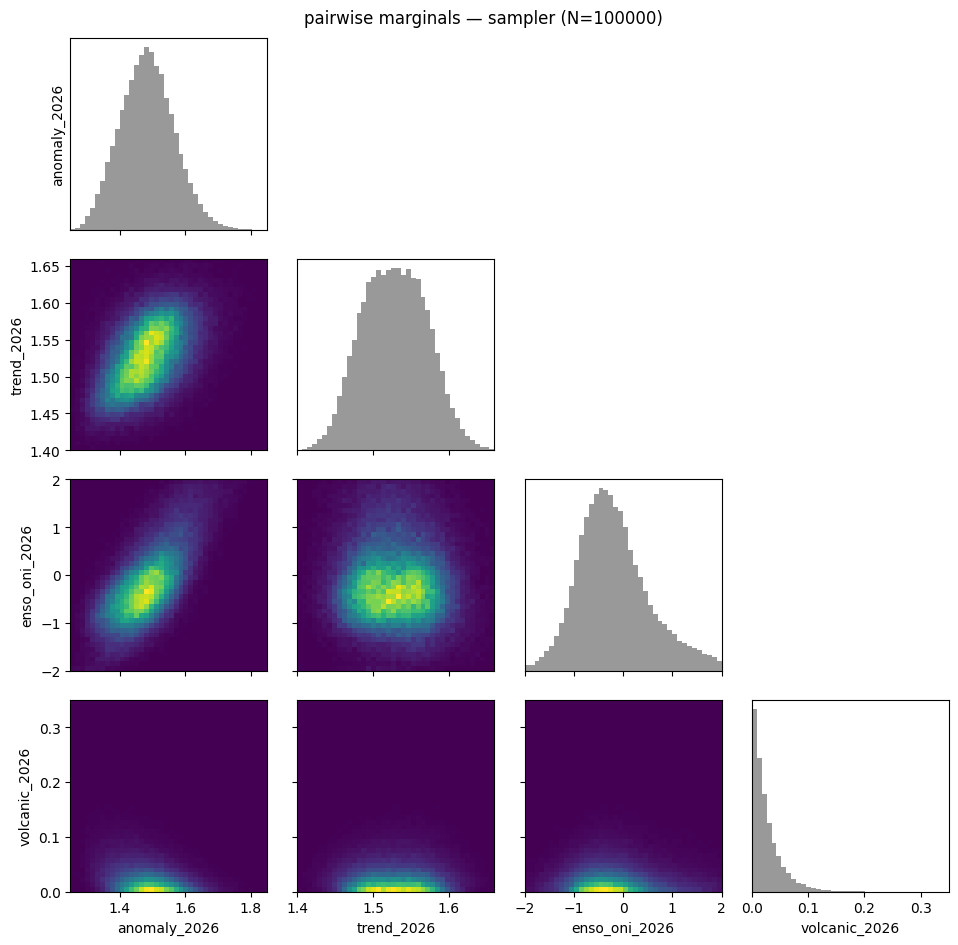

In [17]:
from calibrated_response.maxent_sampler.plotting import plot_pairwise
import matplotlib.pyplot as plt

fig, axes = plot_pairwise(b.model, b.params, n_samples=100_000)
plt.show()

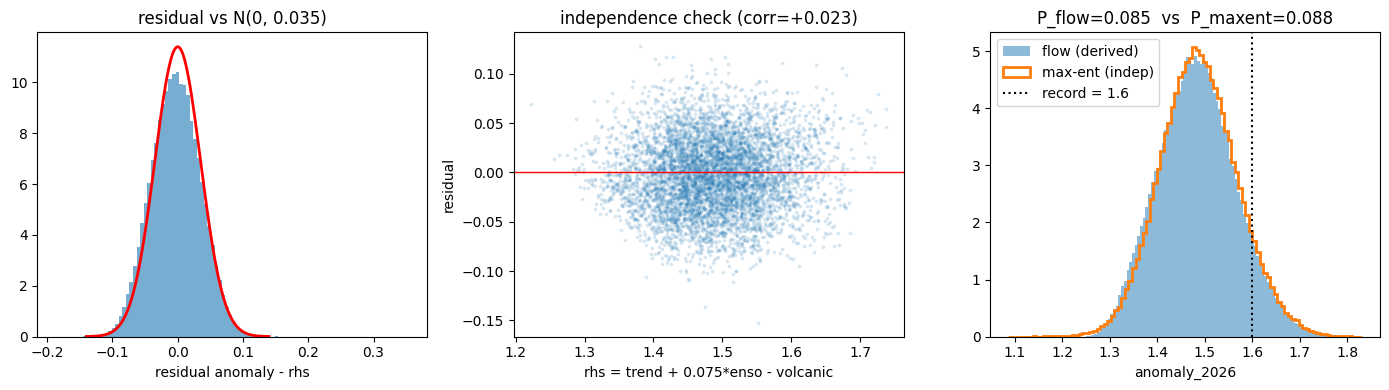

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# 1. residual marginal vs N(0, 0.035)
ax[0].hist(r, bins=100, density=True, alpha=0.6)
rr = np.linspace(-4 * NOISE, 4 * NOISE, 200)
ax[0].plot(rr, np.exp(-rr**2 / (2 * NOISE**2)) / (NOISE * np.sqrt(2 * np.pi)), "r-", lw=2)
ax[0].set(xlabel="residual anomaly - rhs", title=f"residual vs N(0, {NOISE})")

# 2. does the residual stay independent of the rhs? (clipping shows as a downward tilt)
ax[1].scatter(rhs[:6000], r[:6000], s=3, alpha=0.12)
ax[1].axhline(0, color="r", lw=1)
ax[1].set(xlabel="rhs = trend + 0.075*enso - volcanic", ylabel="residual",
          title=f"independence check (corr={np.corrcoef(rhs, r)[0,1]:+.3f})")

# 3. anomaly marginal: derived flow tail vs reconvolved-independent max-ent tail
ax[2].hist(an, bins=100, density=True, alpha=0.5, label="flow (derived)")
ax[2].hist(recon, bins=100, density=True, histtype="step", lw=2, label="max-ent (indep)")
ax[2].axvline(RECORD, color="k", ls=":", label=f"record = {RECORD}")
ax[2].set(xlabel="anomaly_2026", title="P_flow=%.3f  vs  P_maxent=%.3f" %
          (np.mean(an > RECORD), np.mean(recon > RECORD)))
ax[2].legend()

plt.tight_layout()